### ConvLSTM Model

In [1]:
#Libaries being used for ConvLSTM Model
import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, Reshape,Dropout
from skimage.transform import resize
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import ocf_blosc2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2DTranspose, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, TimeDistributed, Conv2DTranspose, Dropout, MaxPooling3D
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\taimo\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
# Load the dataset
SATELLITE_ZARR_PATH = "gs://public-datasets-eumetsat-solar-forecasting/satellite/EUMETSAT/SEVIRI_RSS/v4/2023_hrv.zarr"
dataset = xr.open_dataset(SATELLITE_ZARR_PATH, engine="zarr", chunks="auto")


dataset = dataset.sortby('time')

# Defining time points
times = ["2023-08-10T12:00:00", "2023-08-10T12:10:00", "2023-08-10T12:20:00", "2023-08-10T12:30:00", "2023-08-10T12:40:00",
    "2023-08-10T12:50:00", "2023-08-10T13:00:00", "2023-08-10T13:10:00", "2023-08-10T13:20:00", "2023-08-10T13:30:00",
    "2023-08-10T13:40:00", "2023-08-10T13:50:00", "2023-08-10T14:00:00", "2023-08-10T14:10:00", "2023-08-10T14:20:00",
    "2023-08-10T14:30:00", "2023-08-10T14:40:00", "2023-08-10T14:50:00", "2023-08-10T15:00:00", "2023-08-10T15:10:00",
    "2023-08-10T15:20:00", "2023-08-10T15:30:00", "2023-08-10T15:40:00", "2023-08-10T15:50:00", "2023-08-10T16:00:00",
    "2023-08-10T16:10:00", "2023-08-10T16:20:00", "2023-08-10T16:30:00", "2023-08-10T16:40:00", "2023-08-10T16:50:00",
    "2023-08-10T17:00:00"]

# Coordinates for south of England
x_start, x_end = 1850, 2200  # x-coordinates
y_start, y_end = 3150, 3300  # y-coordinates

# Preprocessing the image
def preprocess_data(data, downscale_size=(80, 80)):
    data_subsets = [d.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))['data'].squeeze('variable', drop=True) for d in data]
    norm_data = [(d - d.min()) / (d.max() - d.min()) for d in data_subsets]
    images = [(d * 255).astype(np.uint8).values for d in norm_data]
    downscaled_images = [resize(image, downscale_size, anti_aliasing=True) for image in images]
    return np.array(downscaled_images)

# Load and preprocess images
data = [dataset.sel(time=time, method='nearest') for time in times]
images = preprocess_data(data, downscale_size=(80, 80))

# Defining the sequence length
sequence_length = 5

# Creating sequences
X = np.array([images[i:i + sequence_length] for i in range(len(images) - sequence_length)])
y = np.array([images[i + 1:i + sequence_length + 1] for i in range(len(images) - sequence_length)])

# Adding channel dimension for greyscale images
X = X[..., np.newaxis]
y = y[..., np.newaxis]

# Spliting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Printing shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

C:\Users\taimo\anaconda3\Lib\site-packages\xarray\core\indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 15 times more chunks
  return self.array[key]
C:\Users\taimo\anaconda3\Lib\site-packages\xarray\core\indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 16 times more chunks
  return self.array[key]


X_train shape: (18, 5, 80, 80, 1)
X_test shape: (8, 5, 80, 80, 1)
y_train shape: (18, 5, 80, 80, 1)
y_test shape: (8, 5, 80, 80, 1)


### Model 1

C:\Users\taimo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 80, 80, 64)  │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 80, 80, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 80, 80, 1)   │           577 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,849 (589.25 KB)

 Trainable params: 150,721 (588.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 349ms/step - loss: 0.0747 - val_loss: 0.0742
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - loss: 0.0452 - val_loss: 0.0479
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - loss: 0.0206 - val_loss: 0.0331
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - loss: 0.0128 - val_loss: 0.0336
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - loss: 0.0117 - val_loss: 0.0338
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - loss: 0.0090 - val_loss: 0.0332
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - loss: 0.0106 - val_loss: 0.0325
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - loss: 0.0113 - val_loss: 0.0321
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - loss: 0.0086 - val_loss: 0.0321
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 408ms/step - loss: 0.0112 - val_loss: 0.0320
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - loss: 0.0102 - val_loss: 0.0317
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step

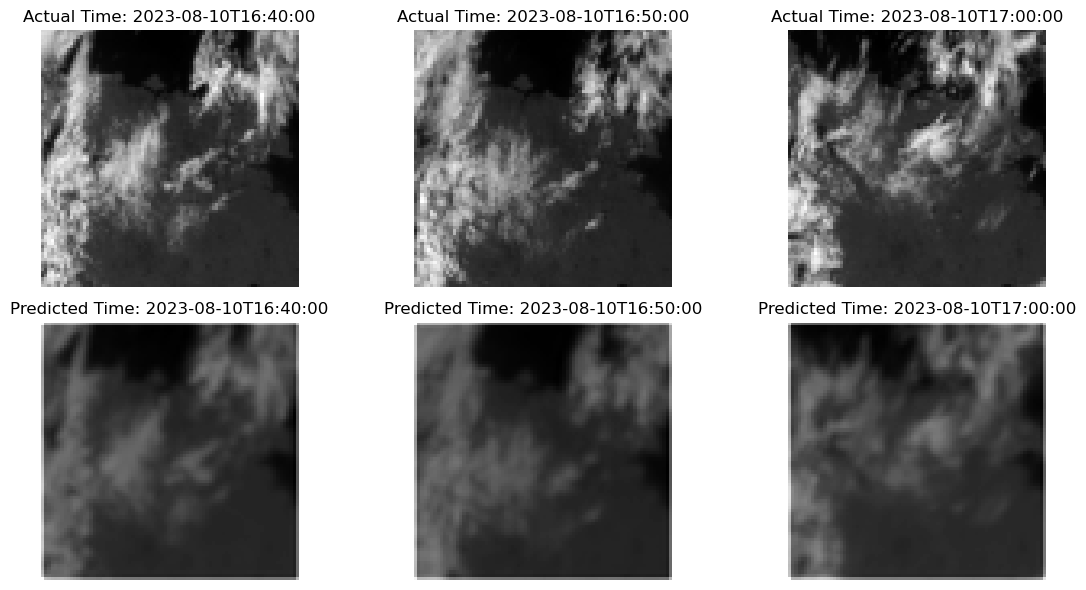

Average SSIM: 0.18949624841915683


In [3]:
# Function to build the ConvLSTM model
# Sequential linear model
# ConvLSTM2D a layer that handels 2D spatial data over sequence, combines convolution operations into LSTM units
# Conv2DTranspose a deconvolutional layer (essentially performing the inverse of a convolution operation) 

def build_model(input_shape):
    model = Sequential([
        ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        TimeDistributed(Conv2DTranspose(filters=1, kernel_size=(3, 3), padding='same', activation='sigmoid'))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Building and compiling the model
input_shape = X_train.shape[1:]  # (sequence_length, height, width, channels)
model = build_model(input_shape)
model.summary()

# Training the model
history = model.fit(X_train, y_train, epochs=20, batch_size=1, validation_split=0.2)

# Generating predictions using the model
predictions = model.predict(X_test)

# Visualizations and Evaluations
def visualize_and_evaluate_predictions(y_true, y_pred, times, sequence_length, n=3):
    plt.figure(figsize=(12, 6))
    ssim_values = []

    for i in range(n):
        index = len(y_true) - n + i
        actual_time = times[len(times) - len(y_true) + sequence_length + i] # Ensuring to get the time after the sequence

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(y_true[index, -1].squeeze(), cmap='gray')
        plt.title(f'Actual Time: {actual_time}')
        plt.axis('off')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(y_pred[index, -1].squeeze(), cmap='gray')
        plt.title(f'Predicted Time: {actual_time}')
        plt.axis('off')

        # SSIM for each pair
        ssim_value = ssim(y_true[index, -1].squeeze(), y_pred[index, -1].squeeze(), data_range=y_pred[index, -1].max() - y_pred[index, -1].min())
        ssim_values.append(ssim_value)

    plt.tight_layout()
    plt.show()

    # Printing average SSIM
    print(f'Average SSIM: {np.mean(ssim_values)}')

visualize_and_evaluate_predictions(y_test, predictions, times, sequence_length)


### Model 1 Results

Mean Squared Error: 0.028635884193120263
Mean Absolute Error: 0.1303184441048029
Root Mean Squared Error: 0.16922140583602377
Mean Absolute Percentage Error: 170.42389188639234
R-squared: 0.14133377437070416


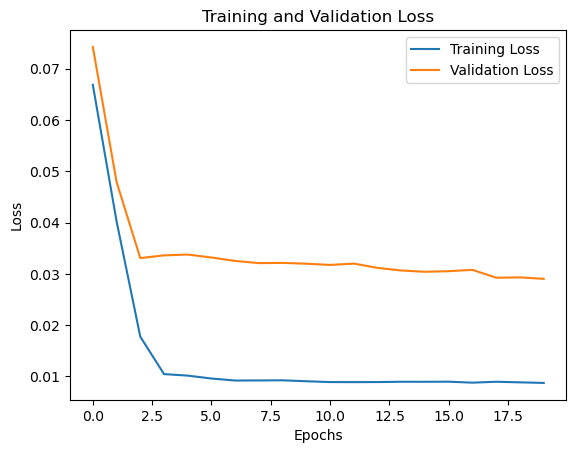

In [4]:
# Calculating evaluation metrics
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.flatten() - predictions.flatten()) / y_test.flatten())) * 100
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

# Plotting training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model 2 (FINAL MSE Loss function)
#### 1. Adjusted model with increase in epochs 
#### 2. Adding more filters


C:\Users\taimo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 80, 80, 64)  │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 80, 80, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 80, 80, 64)  │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 80, 80, 32)  │        18,464 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 80, 80, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 80, 80, 1)   │           289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,337 (806.00 KB)

 Trainable params: 206,017 (804.75 KB)

 Non-trainable params: 320 (1.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Output shape: (1, 5, 80, 80, 1)
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - loss: 0.1041 - val_loss: 0.0752
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - loss: 0.0507 - val_loss: 0.0613
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - loss: 0.0376 - val_loss: 0.0493
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.0316 - val_loss: 0.0375
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - loss: 0.0242 - val_loss: 0.0314
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - loss: 0.0186 - val_loss: 0.0297
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - loss: 0.0213 - val_loss: 0.0344
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - loss: 0.0241 - val_loss: 0.0374
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - loss: 0.0169 - val_loss: 0.0308
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.0128 - val_loss: 0.0292
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - loss: 0.0119 

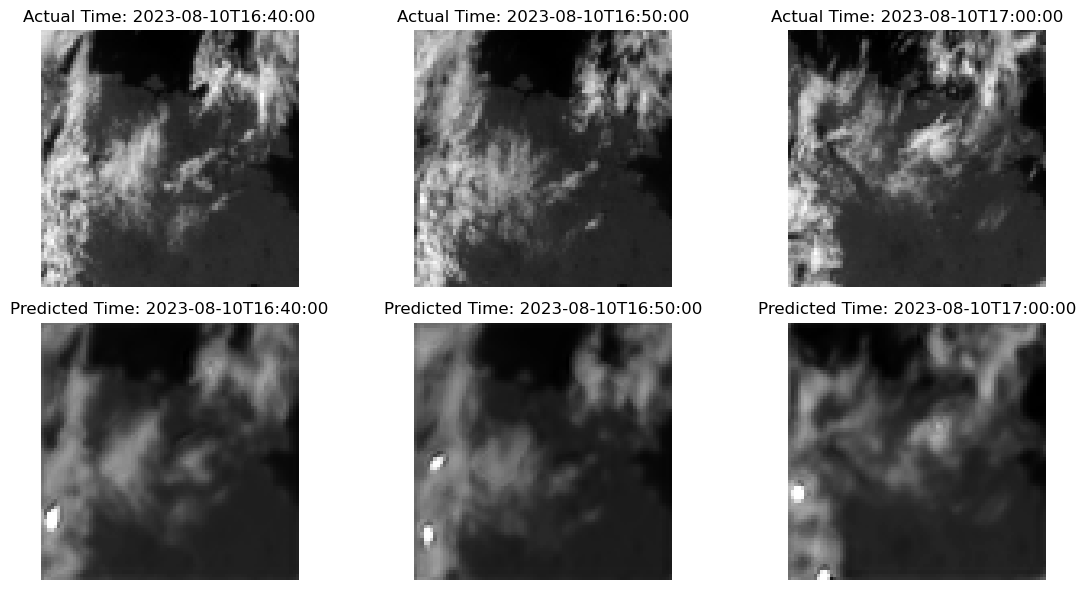

Average SSIM: 0.734353139477316


In [3]:
def build_model_corrected_upsampling(input_shape):
    model = Sequential([
        ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        TimeDistributed(Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=1, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='sigmoid'))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


# X_train is shaped as (batch_size, 5, 80, 80, 1)
model = build_model_corrected_upsampling(input_shape=(5, 80, 80, 1))
model.summary()

# Small batch of random data to check output dimensions
# A sequence of 5 random 80x80 images
output = model.predict(np.random.rand(1, 5, 80, 80, 1))
print("Output shape:", output.shape)  # Expected to be (1, 5, 80, 80, 1)


# Training model
history = model.fit(X_train, y_train, epochs=50, batch_size=1, validation_split=0.2)

# Evaluating and visualizing predictions
predictions = model.predict(X_test)

def visualize_and_evaluate_predictions(y_true, y_pred, times, sequence_length, n=3):
    plt.figure(figsize=(12, 6))
    ssim_values = []

    for i in range(n):
        index = len(y_true) - n + i
        actual_time = times[len(times) - len(y_true) + sequence_length + i]  # Ensuring to get the time after the sequence

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(y_true[index, -1].squeeze(), cmap='gray')
        plt.title(f'Actual Time: {actual_time}')
        plt.axis('off')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(y_pred[index, -1].squeeze(), cmap='gray')
        plt.title(f'Predicted Time: {actual_time}')
        plt.axis('off')

        # SSIM for each pair
        ssim_value = ssim(y_true[index, -1].squeeze(), y_pred[index, -1].squeeze(), data_range=y_pred[index, -1].max() - y_pred[index, -1].min())
        ssim_values.append(ssim_value)

    plt.tight_layout()
    plt.show()

    # Printing average SSIM
    print(f'Average SSIM: {np.mean(ssim_values)}')

visualize_and_evaluate_predictions(y_test, predictions, times, sequence_length)


### Model 2 Results

Mean Squared Error: 0.008531966140308423
Mean Absolute Error: 0.06400376454216133
Root Mean Squared Error: 0.09236864262458566
Mean Absolute Percentage Error: 75.64901510281237
R-squared: 0.7441632633555741


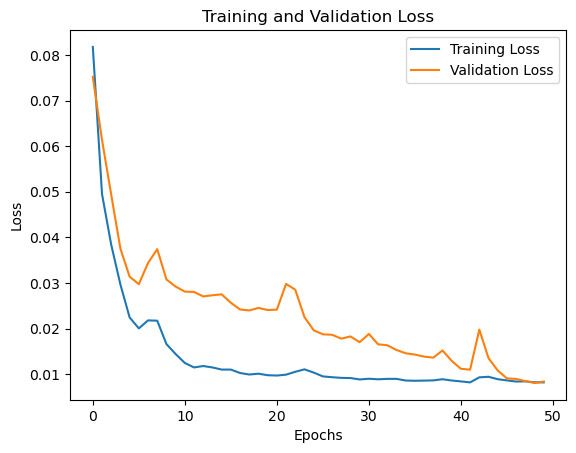

In [4]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.flatten() - predictions.flatten()) / y_test.flatten())) * 100
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

# Plot training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model 3.
#### 1. L1 regularizer is used

C:\Users\taimo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_12 (ConvLSTM2D)     │ (None, 5, 80, 80, 64)  │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 5, 80, 80, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 5, 80, 80, 64)  │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_24             │ (None, 5, 80, 80, 32)  │        18,464 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 5, 80, 80, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_25             │ (None, 5, 80, 80, 1)   │           289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,337 (806.00 KB)

 Trainable params: 206,017 (804.75 KB)

 Non-trainable params: 320 (1.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Output shape: (1, 5, 80, 80, 1)
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - loss: 0.1298 - val_loss: 0.0907
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - loss: 0.0573 - val_loss: 0.0818
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - loss: 0.0415 - val_loss: 0.0705
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - loss: 0.0322 - val_loss: 0.0520
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - loss: 0.0240 - val_loss: 0.0401
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - loss: 0.0211 - val_loss: 0.0345
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - loss: 0.0169 - val_loss: 0.0300
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - loss: 0.0203 - val_loss: 0.0325
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - loss: 0.0152 - val_loss: 0.0289
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - loss: 0.0128 - val_loss: 0.0277
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.0107 

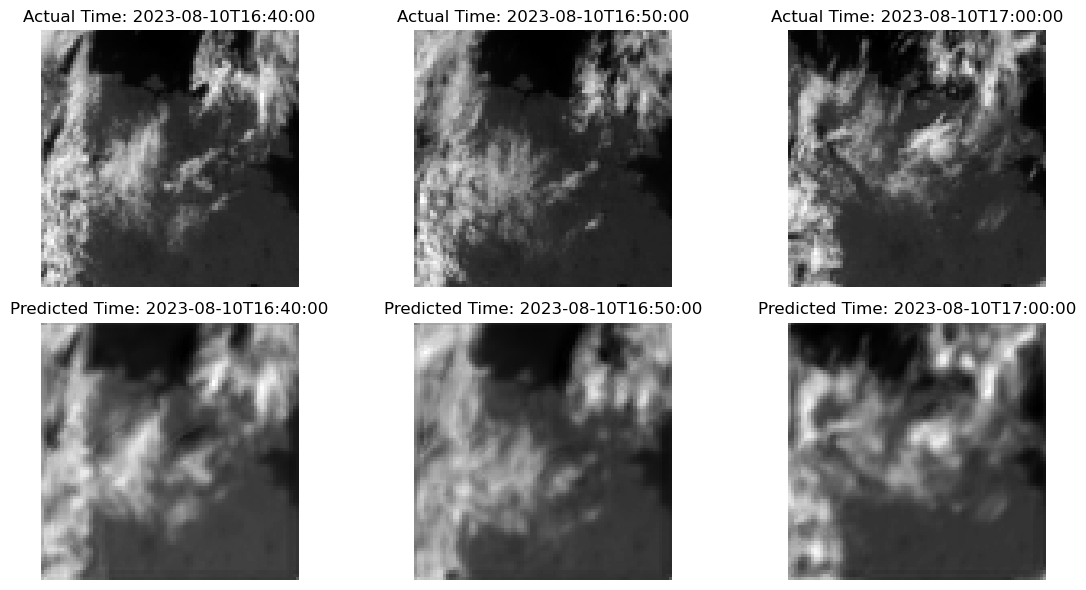

Average SSIM: 0.6849752019062582


In [20]:
def build_advanced_model(input_shape):
    model = Sequential([
        ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu', input_shape=input_shape, kernel_regularizer=l1(0.01)),
        BatchNormalization(),
        Dropout(0.2),
        TimeDistributed(Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=1, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='sigmoid'))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_model_corrected_upsampling(input_shape=(5, 80, 80, 1))
model.summary()

# A sequence of 5 random 80x80 images
output = model.predict(np.random.rand(1, 5, 80, 80, 1))
print("Output shape:", output.shape)  # Expected to be (1, 5, 80, 80, 1)

history = model.fit(X_train, y_train, epochs=50, batch_size=1, validation_split=0.2)

predictions = model.predict(X_test)

def visualize_and_evaluate_predictions(y_true, y_pred, times, sequence_length, n=3):
    plt.figure(figsize=(12, 6))
    ssim_values = []

    for i in range(n):
        index = len(y_true) - n + i
        actual_time = times[len(times) - len(y_true) + sequence_length + i]  # Ensuring to get the time after the sequence

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(y_true[index, -1].squeeze(), cmap='gray')
        plt.title(f'Actual Time: {actual_time}')
        plt.axis('off')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(y_pred[index, -1].squeeze(), cmap='gray')
        plt.title(f'Predicted Time: {actual_time}')
        plt.axis('off')

        # SSIM for each pair
        ssim_value = ssim(y_true[index, -1].squeeze(), y_pred[index, -1].squeeze(), data_range=y_pred[index, -1].max() - y_pred[index, -1].min())
        ssim_values.append(ssim_value)

    plt.tight_layout()
    plt.show()

    print(f'Average SSIM: {np.mean(ssim_values)}')

visualize_and_evaluate_predictions(y_test, predictions, times, sequence_length)


### Model 3 Results

Mean Squared Error: 0.008700291614890528
Mean Absolute Error: 0.06856593020691662
Root Mean Squared Error: 0.0932753537376864
Mean Absolute Percentage Error: 77.6767016631784
R-squared: 0.7391159109161688


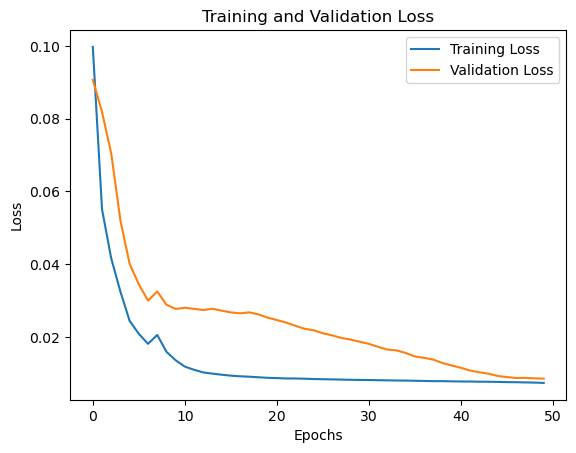

In [21]:
# Calculating evaluation metrics
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.flatten() - predictions.flatten()) / y_test.flatten())) * 100
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

# Ploting training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model 4
#### 1. L2 regularization

C:\Users\taimo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_6 (ConvLSTM2D)      │ (None, 5, 80, 80, 64)  │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 80, 80, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 80, 80, 64)  │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 5, 80, 80, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 80, 80, 32)  │        18,464 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 5, 80, 80, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 80, 80, 1)   │           289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,337 (806.00 KB)

 Trainable params: 206,017 (804.75 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 0.2314 - val_loss: 0.1657
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 0.1399 - val_loss: 0.1394
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - loss: 0.1133 - val_loss: 0.1191
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - loss: 0.0929 - val_loss: 0.0997
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 0.0847 - val_loss: 0.0905
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - loss: 0.0697 - val_loss: 0.0800
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - loss: 0.0615 - val_loss: 0.0747
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - loss: 0.0591 - val_loss: 0.0708
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - loss: 0.0531 - val_loss: 0.0745
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - loss: 0.0557 - val_loss: 0.1070
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - loss: 0.0523 - val_loss: 0.0927
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step

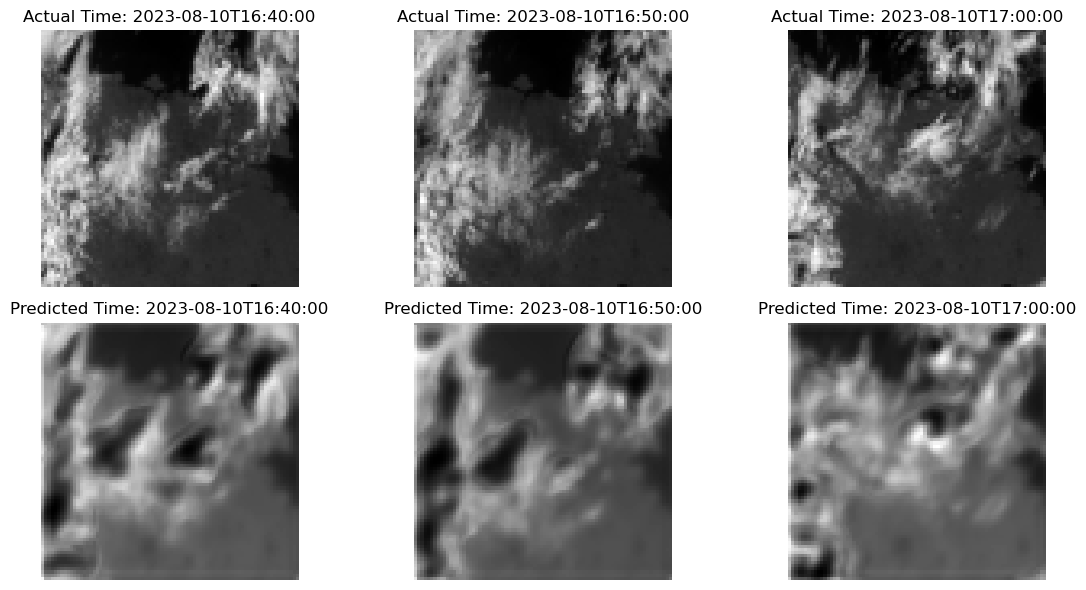

Average SSIM: 0.42768584969069656


In [12]:
def build_model_with_regularization(input_shape):
    model = Sequential([
        ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu', kernel_regularizer=l2(0.001), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        TimeDistributed(Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=1, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='sigmoid'))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# summarizing the model
regularized_model = build_model_with_regularization(input_shape=(5, 80, 80, 1))
regularized_model.summary()

history = regularized_model.fit(X_train, y_train, epochs=50, batch_size=1, validation_split=0.2)

predictions = regularized_model.predict(X_test)

def visualize_and_evaluate_predictions(y_true, y_pred, times, sequence_length, n=3):
    plt.figure(figsize=(12, 6))
    ssim_values = []

    for i in range(n):
        index = len(y_true) - n + i
        actual_time = times[len(times) - len(y_true) + sequence_length + i]  # Ensuring to get the time after the sequence

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(y_true[index, -1].squeeze(), cmap='gray')
        plt.title(f'Actual Time: {actual_time}')
        plt.axis('off')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(y_pred[index, -1].squeeze(), cmap='gray')
        plt.title(f'Predicted Time: {actual_time}')
        plt.axis('off')

        # SSIM for each pair
        ssim_value = ssim(y_true[index, -1].squeeze(), y_pred[index, -1].squeeze(), data_range=y_pred[index, -1].max() - y_pred[index, -1].min())
        ssim_values.append(ssim_value)

    plt.tight_layout()
    plt.show()

    print(f'Average SSIM: {np.mean(ssim_values)}')

visualize_and_evaluate_predictions(y_test, predictions, times, sequence_length)



### Model 4 results

Mean Squared Error: 0.016427032954536548
Mean Absolute Error: 0.09264963029891664
Root Mean Squared Error: 0.12816798724539816
Mean Absolute Percentage Error: 100.09380791178887
R-squared: 0.5074243808840115


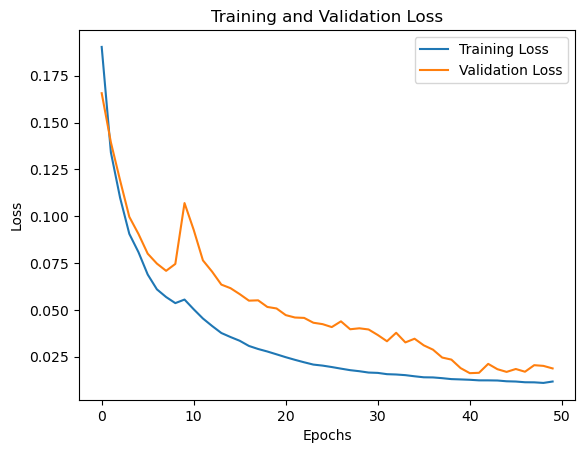

In [13]:
# Calculating evaluation metrics
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.flatten() - predictions.flatten()) / y_test.flatten())) * 100
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")


# Ploting training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model 5 (Final Combined MSE & SSIM loss function)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.2784 - val_loss: 0.2053
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 0.2219 - val_loss: 0.1968
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - loss: 0.1950 - val_loss: 0.1870
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - loss: 0.1775 - val_loss: 0.1787
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - loss: 0.1624 - val_loss: 0.1716
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 0.1489 - val_loss: 0.1657
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - loss: 0.1382 - val_loss: 0.1608
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - loss: 0.1306 - val_loss: 0.1570
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - loss: 0.1253 - val_loss: 0.1541
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - loss: 0.1216 - val_loss: 0.1512
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - loss: 0.1180 - val_loss: 0.1481
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step

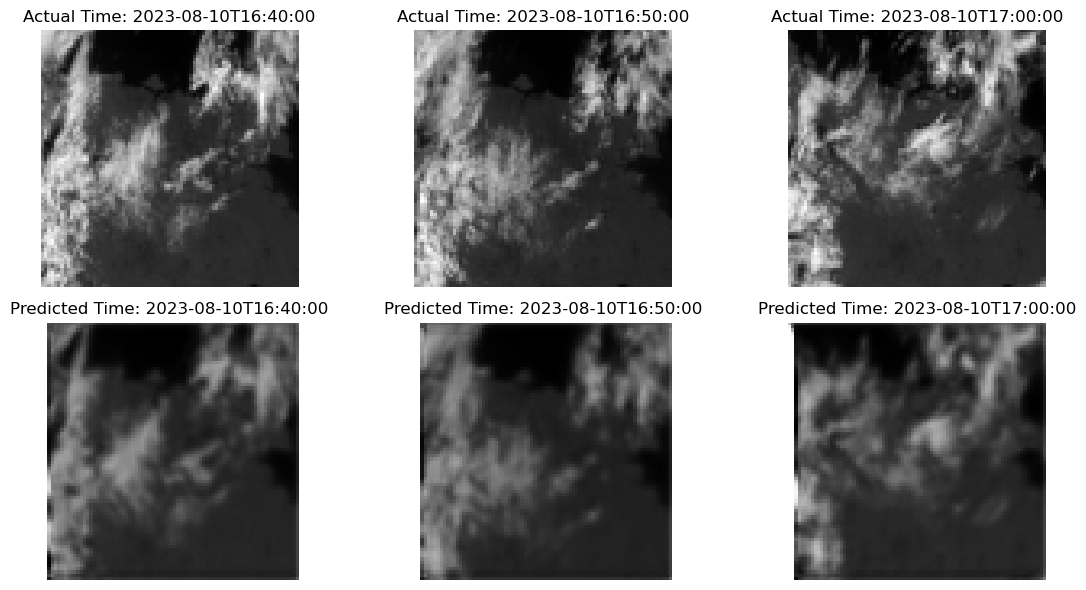

Average SSIM: 0.7711213919786607


In [15]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Defining SSIM loss function
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# Combined loss function
def combined_loss(y_true, y_pred, alpha=0.84):
    mse = tf.keras.losses.MeanSquaredError()(y_true, y_pred)
    ssim = ssim_loss(y_true, y_pred)
    return (alpha * mse) + ((1 - alpha) * ssim)

def build_model(input_shape, l2_strength=0.001):
    model = Sequential([
        ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu',
                   kernel_regularizer=l2(l2_strength)),
        BatchNormalization(),
        Dropout(0.5),  # Increased dropout
        TimeDistributed(Conv2DTranspose(filters=64, kernel_size=(3, 3), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=32, kernel_size=(3, 3), padding='same', activation='relu')),
        BatchNormalization(),
        TimeDistributed(Conv2DTranspose(filters=1, kernel_size=(3, 3), padding='same', activation='sigmoid'))
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss=lambda y_true, y_pred: combined_loss(y_true, y_pred, alpha=0.84))
    return model


# Building the model
model = build_model(input_shape=(5, 80, 80, 1))

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=50, batch_size=1, validation_split=0.2, callbacks=[early_stopping])

predictions = model.predict(X_test)

def visualize_and_evaluate_predictions(y_true, y_pred, times, sequence_length, n=3):
    plt.figure(figsize=(12, 6))
    ssim_values = []

    for i in range(n):
        index = len(y_true) - n + i
        actual_time = times[len(times) - len(y_true) + sequence_length + i]  # Ensuring to get the time after the sequence

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(y_true[index, -1].squeeze(), cmap='gray')
        plt.title(f'Actual Time: {actual_time}')
        plt.axis('off')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(y_pred[index, -1].squeeze(), cmap='gray')
        plt.title(f'Predicted Time: {actual_time}')
        plt.axis('off')

        # SIM for each pair
        ssim_value = ssim(y_true[index, -1].squeeze(), y_pred[index, -1].squeeze(), data_range=y_pred[index, -1].max() - y_pred[index, -1].min())
        ssim_values.append(ssim_value)

    plt.tight_layout()
    plt.show()

    print(f'Average SSIM: {np.mean(ssim_values)}')

visualize_and_evaluate_predictions(y_test, predictions, times, sequence_length)



### Model 5 Results

Mean Squared Error: 0.015070423133972645
Mean Absolute Error: 0.07299100125913527
Root Mean Squared Error: 0.12276165172386956
Mean Absolute Percentage Error: 67.44825201610105
R-squared: 0.5481032377483338


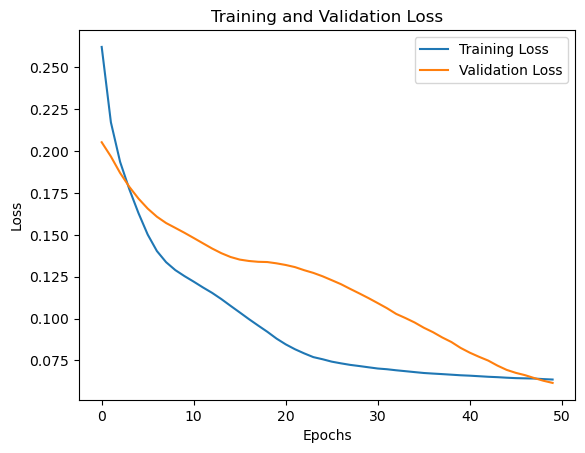

In [16]:
# Calculating evaluation metrics
mse = mean_squared_error(y_test.flatten(), predictions.flatten())
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.flatten() - predictions.flatten()) / y_test.flatten())) * 100
r2 = r2_score(y_test.flatten(), predictions.flatten())

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R-squared: {r2}")

# Ploting training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()